<a href="https://colab.research.google.com/github/NestorRubin/telecomX_part_2.ipynb/blob/main/telecomX_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1️⃣ Cargar los datos tratados**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving datos_tratados.csv to datos_tratados.csv


In [ ]:
import pandas as pd

df = pd.read_csv("datos_tratados.csv")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,DailyCharges
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


#**2️⃣ Limpieza de datos**

Eliminamos valores faltantes que puedan afectar los modelos.

In [ ]:
df = df.dropna()

Eliminamos columnas irrelevantes para el modelado.

In [ ]:
df = df.drop(columns=["customerID"])

#**3️⃣ Encoding de variables categóricas**

Convertimos variables categóricas a formato numérico.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Churn,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,DailyCharges,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


#**4️⃣ Análisis de proporción de cancelación**

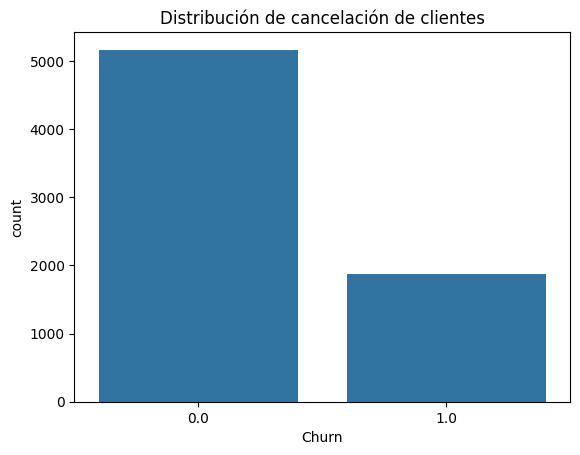

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title("Distribución de cancelación de clientes")

plt.show()

#**5️⃣ Matriz de correlación**

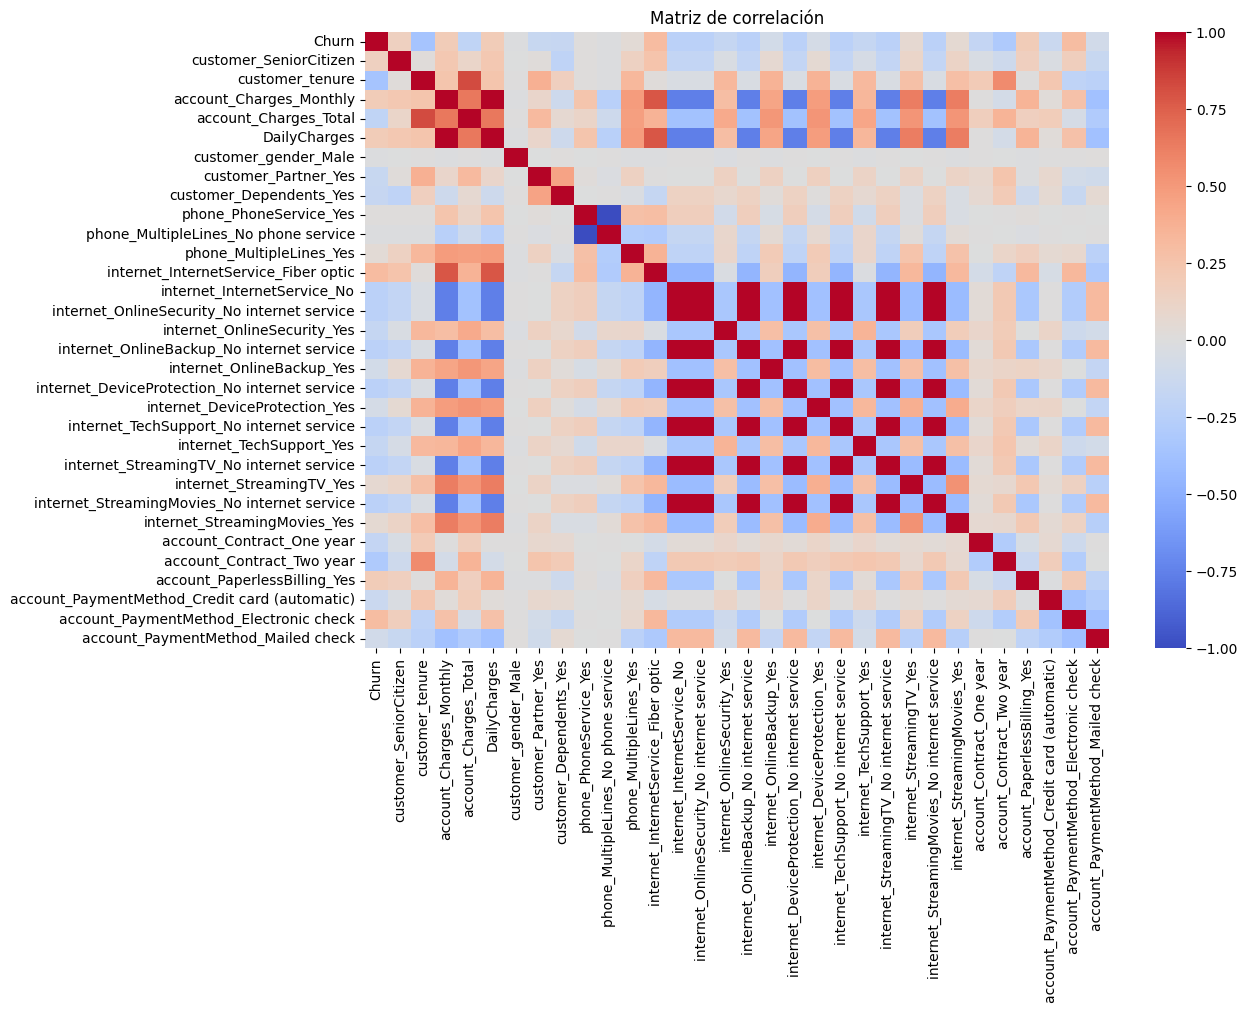

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

#**6️⃣ Separación de variables**

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

#**7️⃣ División de datos**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#**8️⃣ Normalización de datos**

La normalización es necesaria para modelos basados en distancia como la Regresión Logística.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#**9️⃣ Modelo 1: Regresión Logística**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

#**🔟 Modelo 2: Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

#**1️⃣1️⃣ Evaluación de modelos**

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

Regresión Logística

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.7967306325515281
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1033
         1.0       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



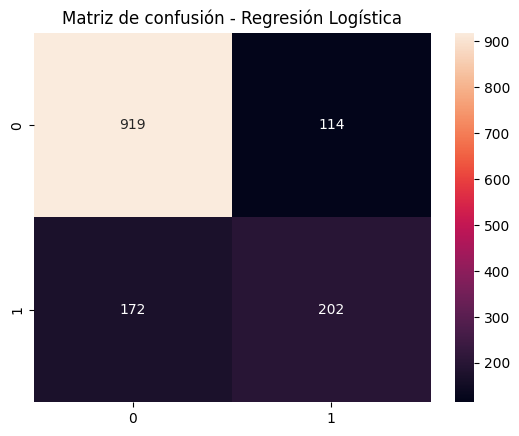

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusión - Regresión Logística")

plt.show()

Random Forest

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7889125799573561
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1033
         1.0       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



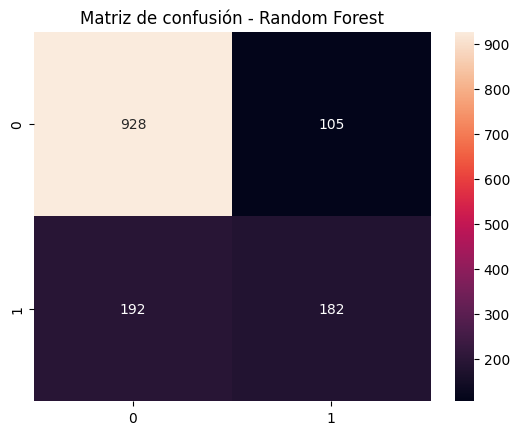

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusión - Random Forest")

plt.show()

#**1️⃣2️⃣ Importancia de variables**

In [ ]:
import pandas as pd

importances = rf_model.feature_importances_

features = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importances
})

features = features.sort_values(by="Importancia", ascending=False)

features.head(10)

,Variable,Importancia
3,account_Charges_Total,0.168522
1,customer_tenure,0.161699
2,account_Charges_Monthly,0.126442
4,DailyCharges,0.125957
11,internet_InternetService_Fiber optic,0.037010
29,account_PaymentMethod_Electronic check,0.035108
26,account_Contract_Two year,0.032625
5,customer_gender_Male,0.024122
27,account_PaperlessBilling_Yes,0.023155
14,internet_OnlineSecurity_Yes,0.022246


Gráfico:

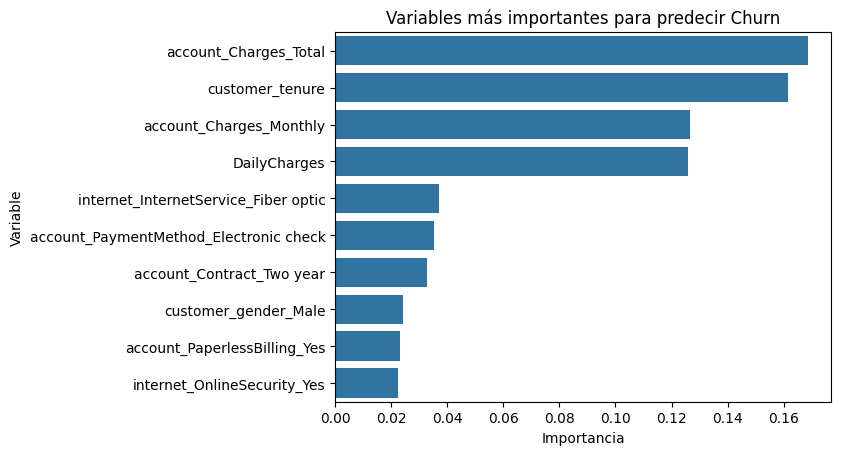

In [ ]:
sns.barplot(
    x="Importancia",
    y="Variable",
    data=features.head(10)
)

plt.title("Variables más importantes para predecir Churn")

plt.show()

#**1️⃣3️⃣ Conclusión**

##Resultados

Se entrenaron dos modelos de clasificación para predecir la cancelación de clientes:

* Regresión Logística

* Random Forest

El modelo Random Forest mostró mejor capacidad para capturar relaciones complejas entre las variables.

##Factores más importantes en la cancelación

Las variables más relevantes para la predicción fueron:

* Tipo de contrato

* Antigüedad del cliente (tenure)

* Cargos mensuales

* Método de pago

* Servicios adicionales contratados

##Estrategias de retención

Basándose en el análisis, se sugieren las siguientes estrategias:

* Incentivar contratos de mayor duración mediante descuentos.

* Crear programas de fidelización para clientes nuevos.

* Ofrecer paquetes de servicios con mejor relación costo-beneficio.

* Mejorar la atención al cliente y soporte técnico.

Estas acciones pueden ayudar a reducir la tasa de cancelación y mejorar la retención de clientes.